Numba imported
73705


/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


Cluster 0 Center: x=4101.35, y=4098.84
Cluster 1 Center: x=4100.02, y=4102.18
Cluster 0 Spread (Scaled Units): x_std=1.05, y_std=1.14, theta=75.85
Cluster 1 Spread (Scaled Units): x_std=0.33, y_std=0.84, theta=335.89
Background table should be larger than sources table.
Cluster 0 Center: x=4103.90, y=4095.72
Cluster 1 Center: x=4094.13, y=4100.42
Cluster 2 Center: x=4100.88, y=4098.30
Cluster 3 Center: x=4110.39, y=4100.38
Cluster 0 Spread (Scaled Units): x_std=0.64, y_std=0.83, theta=25.76
Cluster 1 Spread (Scaled Units): x_std=0.62, y_std=1.00, theta=354.27
Cluster 2 Spread (Scaled Units): x_std=1.01, y_std=1.03, theta=12.21
Cluster 3 Spread (Scaled Units): x_std=0.60, y_std=1.10, theta=359.04
Cluster 0 Center: x=4103.00, y=4107.57
Cluster 1 Center: x=4096.10, y=4096.04
Cluster 2 Center: x=4102.50, y=4111.85
Cluster 3 Center: x=4102.97, y=4093.05
Cluster 0 Spread (Scaled Units): x_std=0.34, y_std=0.44, theta=19.32
Cluster 1 Spread (Scaled Units): x_std=0.18, y_std=0.38, theta=95.32
C

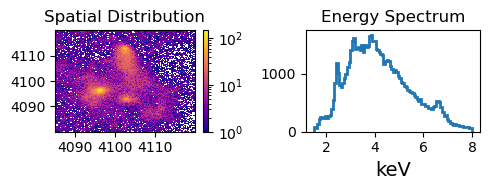

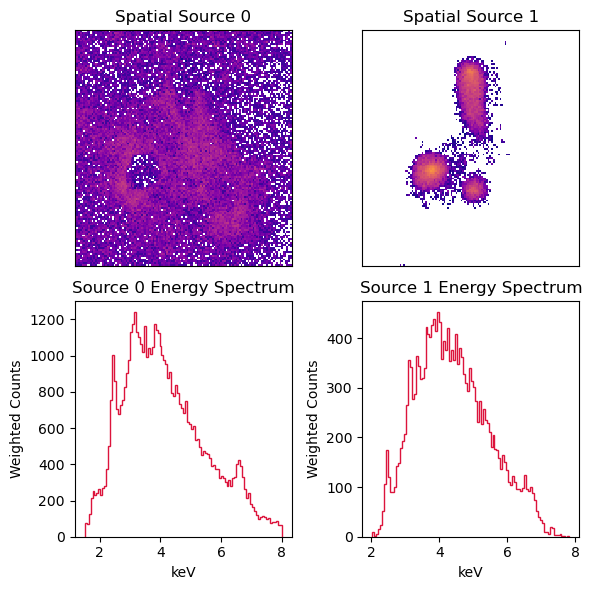

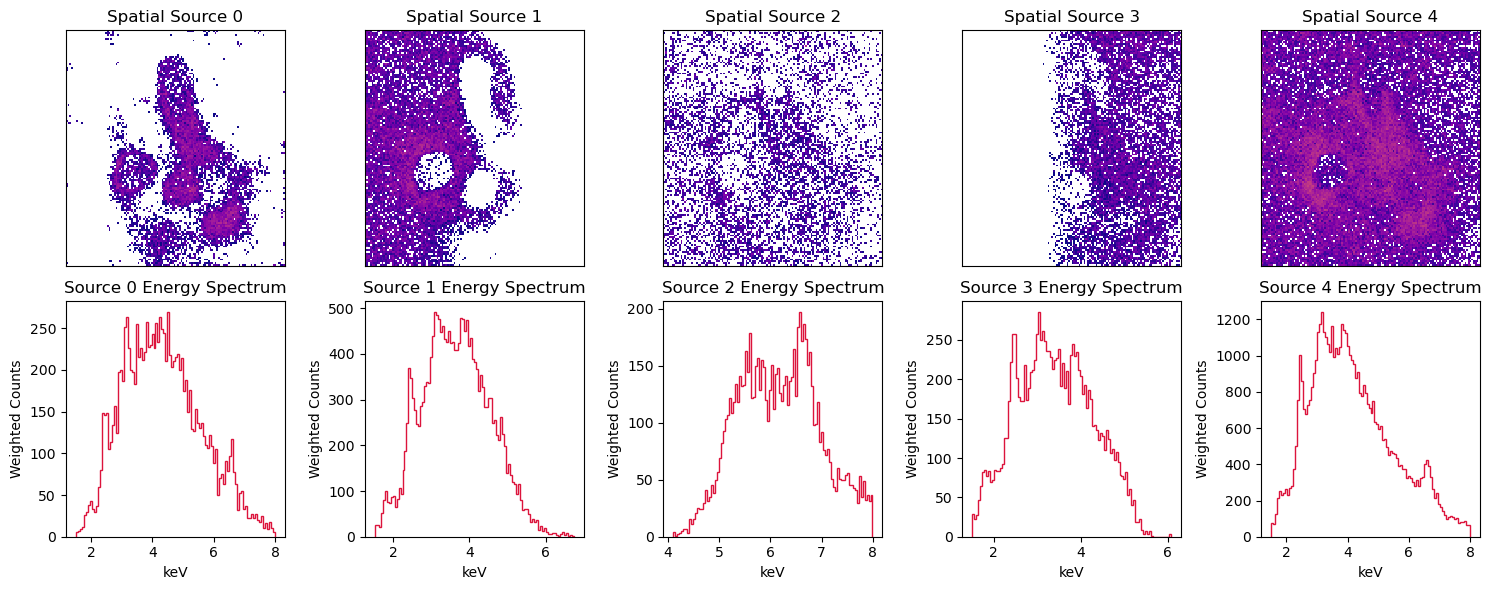

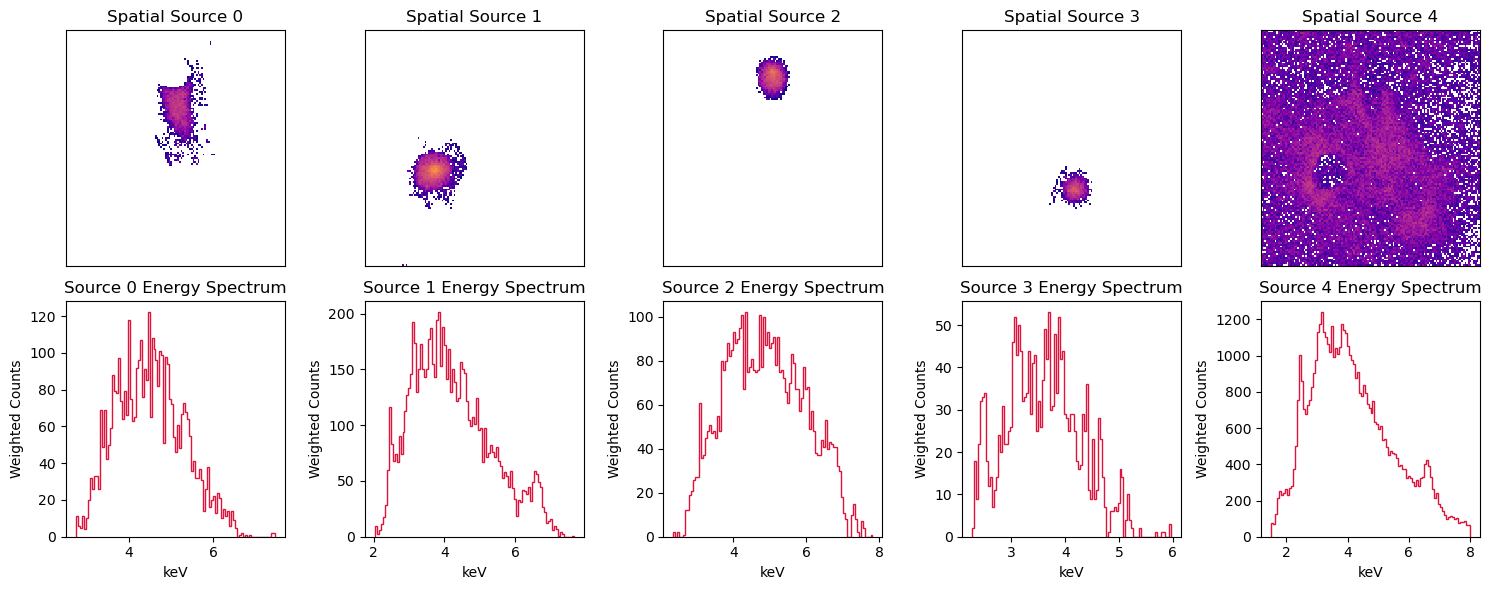

In [1]:
from double_gmm import *

In [2]:
import matplotlib as mpl
from matplotlib.path import Path
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [16]:
def gaussian(x, y, x0, y0, xalpha, yalpha, A):
        return A * np.exp( -((x-x0)/xalpha)**2 -((y-y0)/yalpha)**2)

def _gaussian(M, *args):
    x, y = M
    arr = np.zeros(x.shape)
    for i in range(len(args)//5):
        arr += gaussian(x, y, *args[i*5:i*5+5])
    return arr

def fit_contours_2d(table, initial_center, initial_std):
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()

    # --- Smart Initialization for 2 Gaussians ---
    x0, y0 = initial_center[0], initial_center[1]
    sx, sy = max(initial_std[0], 0.5), max(initial_std[1], 0.5)
    A_max = np.max(counts) if np.max(counts) > 0 else 1.0

    # Gaussian 1: The Core (at the GMM center)
    g1 = [x0, y0, sx, sy, A_max * 0.7]
    
    # Gaussian 2: The "Blobby" Offset (slightly shifted to help the fit start)
    # We shift it by half a sigma to give the solver a direction to pull
    g2 = [x0 + (sx/2), y0 + (sy/2), sx, sy, A_max * 0.3]
    
    p0 = g1 + g2

    # --- Tight Bounds to prevent RuntimeError ---
    # [x0, y0, sx, sy, A] repeated twice
    dist_tol = 15.0 # pixels/units
    
    # Define bounds for one set of 5 parameters
    low_block = [x0 - dist_tol, y0 - dist_tol, 0.1, 0.1, 0]
    high_block = [x0 + dist_tol, y0 + dist_tol, sx * 10, sy * 10, A_max * 2]
    
    lower = low_block * 2
    upper = high_block * 2

    try:
        # Increase maxfev and use a robust method
        popt, pcov = curve_fit(
            _gaussian, 
            xdata_flat, 
            zdata_flat, 
            p0=p0, 
            bounds=(lower, upper),
            maxfev=10000 
        )
    except RuntimeError:
        print(f"Fit failed for source at {x0, y0}. Using GMM priors.")
        return p0 # Return the 10 initial guess parameters as a fallback
        
    return popt

In [17]:
contours = []
cont_lvls = 10

for i in range(len(split_sources)):
    table = split_sources[i]
    
    # PASS THE GMM RESULTS HERE
    # centers[i] is the [x, y] for this specific source
    # std_dev[i] is the [sx, sy, theta] for this specific source
    popt = fit_contours_2d(table, centers[i], std_dev[i])
    
    # Re-calculate grid for plotting the contour
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))

    # Generate the fitted surface
    fit_grid = _gaussian(xdata_flat, *popt).reshape(len(y_centers), len(x_centers))
    
    # Plot
    cont = ax1.contour(X, Y, fit_grid, levels=cont_lvls, colors='white', linewidths=0.8, alpha=0.7)
    contours.append(cont)

In [18]:
def area_of_contour(contour_collection, lvl: int):
    x = contour_collection.get_paths()[lvl].vertices[:,0]
    y = contour_collection.get_paths()[lvl].vertices[:,1]

    area = 0.5*np.sum(y[:-1]*np.diff(x) - x[:-1]*np.diff(y))
    area = np.abs(area)
    return area

def area_of_contour_ring(contour_collection, lvl: int):
    if lvl == 0:
        return area_of_contour(contour_collection, lvl)
    else:
        return area_of_contour(contour_collection, lvl) - area_of_contour(contour_collection, lvl - 1)


def energy_of_contour(contour_collection, data, lvl: int):
    vert = contour_collection.get_paths()[lvl].vertices
    contour_path = Path(vert)
    points = data[['x', 'y']].values
    mask = contour_path.contains_points(points)
    total_energy = data.loc[mask, 'energy'].sum()
    return total_energy

def energy_of_contour_ring(contour_collection, data, lvl: int):
    if lvl == 0:
        return energy_of_contour(contour_collection, data, lvl)
    else:
        return energy_of_contour(contour_collection, data, lvl) - energy_of_contour(contour_collection, data, lvl - 1)
    
def energy_density_ring(contour_collection, data, lvl: int):
    return energy_of_contour_ring(contour_collection, data, lvl) / area_of_contour_ring(contour_collection, lvl)


/tmp/ipykernel_17038/57259721.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return energy_of_contour_ring(contour_collection, data, lvl) / area_of_contour_ring(contour_collection, lvl)
/tmp/ipykernel_17038/57259721.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return energy_of_contour_ring(contour_collection, data, lvl) / area_of_contour_ring(contour_collection, lvl)
/tmp/ipykernel_17038/57259721.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return energy_of_contour_ring(contour_collection, data, lvl) / area_of_contour_ring(contour_collection, lvl)
/tmp/ipykernel_17038/57259721.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return energy_of_contour_ring(contour_collection, data, lvl) / area_of_contour_ring(contour_collection, lvl)


[]


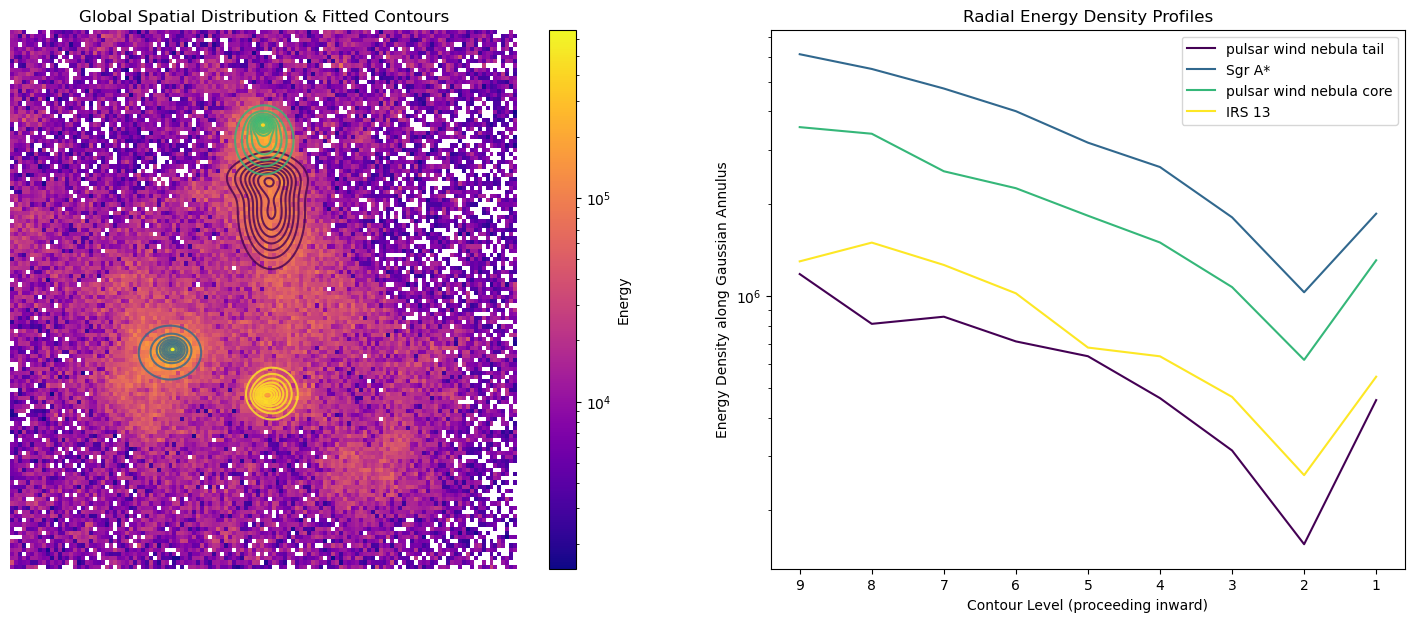

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 weights=subset['energy'],
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Global Spatial Distribution & Fitted Contours')
ax1.set_axis_off()
ax2.set_title('Radial Energy Density Profiles')
ax2.set_xlabel('Contour Level (proceeding inward)')
ax2.set_ylabel('Energy Density along Gaussian Annulus')
ax2.invert_xaxis()
fig.colorbar(h2d[3], ax=ax1, label='Energy')

areas = []
energies = []
cmap = mpl.colormaps['viridis']
colors = cmap(np.linspace(0, 1, len(contours)))
objs = ['pulsar wind nebula tail','Sgr A*', 'pulsar wind nebula core', 'IRS 13']
for obj, cont in enumerate(contours):
    ax1.contour(cont, colors=colors[obj], alpha=0.8)
    energies.append([energy_density_ring(cont, split_sources[obj], i) for i in range(cont_lvls)])
    plt.plot(energies[-1], color=colors[obj], label=objs[obj])
    #plt.plot([energy_of_contour_ring(cont, split_sources[obj], i) for i in range(cont_lvls)], '--')

plt.legend()
plt.yscale('log')
print(areas)
    